In [97]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/navneet0094/jafee-dataset/README_FIRST.txt
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/NM.SA1.98.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/YM.SA3.57.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/KA.DI3.44.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/KM.AN2.18.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/MK.HA3.118.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/NM.FE2.111.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/TM.HA1.180.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/UY.FE2.153.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/UY.DI3.151.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/YM.NE2.50.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/TM.SU3.189.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/MK.NE3.115.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/MK.SA3.121.tiff
/kaggle/input/da

In [98]:
dataset_path = "//kaggle/input/datasets/navneet0094/jafee-dataset/"

print(os.listdir(dataset_path))

['jaffe', 'README_FIRST.txt']


In [99]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

data = []
labels = []

emotion_map = {
    'AN':0, 'DI':1, 'FE':2,
    'HA':3, 'SA':4, 'SU':5, 'NE':6
}

dataset_path = "/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe"

for img_name in os.listdir(dataset_path):

    img_path = os.path.join(dataset_path, img_name)

    try:
        # grayscale
        img = Image.open(img_path).convert('L')

        # resize to 128x128
        img = img.resize((128,128))

        img = np.array(img)

        emotion = img_name.split('.')[1][:2]
        label = emotion_map[emotion]

        data.append(img)
        labels.append(label)

    except Exception as e:
        print("Error:", img_name)

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (213, 128, 128)
Labels: [0 1 2 3 4 5 6]


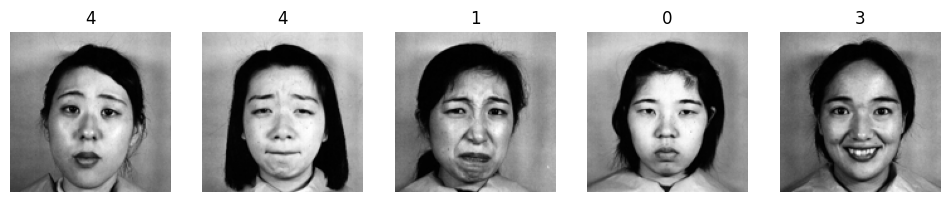

In [100]:
plt.figure(figsize=(12,4))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(data[i], cmap='gray')

    plt.title(labels[i])

    plt.axis('off')

plt.show()

In [101]:
upper_faces = []
middle_faces = []
lower_faces = []

for img in data:
        # Upper -> Eyes + Brows
    upper = img[30:70, :]
    
    # Middle -> Nose + Cheeks
    middle = img[65:105, :]
    
    # Lower -> Mouth + Chin
    lower = img[85:125, :]

    upper_faces.append(upper)
    middle_faces.append(middle)
    lower_faces.append(lower)

upper_faces = np.array(upper_faces)
middle_faces = np.array(middle_faces)
lower_faces = np.array(lower_faces)

print(upper_faces.shape)
print(middle_faces.shape)
print(lower_faces.shape)

(213, 40, 128)
(213, 40, 128)
(213, 40, 128)


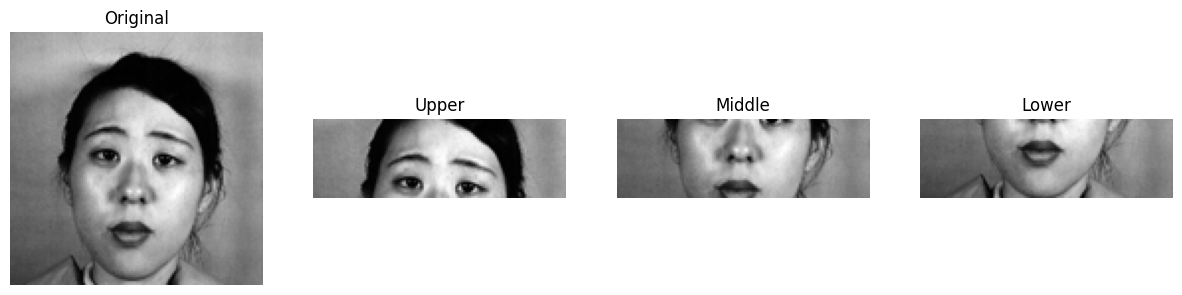

In [102]:
sample = 0

fig, ax = plt.subplots(1,4, figsize=(15,5))

ax[0].imshow(data[sample], cmap='gray')
ax[0].set_title("Original")

ax[1].imshow(upper_faces[sample], cmap='gray')
ax[1].set_title("Upper")

ax[2].imshow(middle_faces[sample], cmap='gray')
ax[2].set_title("Middle")

ax[3].imshow(lower_faces[sample], cmap='gray')
ax[3].set_title("Lower")

for a in ax:
    a.axis('off')

plt.show()

In [103]:
from skimage.feature import hog

In [104]:
def extract_hog_features(images):

    features = []

    for img in images:

        hog_features = hog(
            img,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2),
            block_norm='L2-Hys'
        )

        features.append(hog_features)

    return np.array(features)


In [105]:
# Original Face Features
X_original = extract_hog_features(data)

# Upper Face Features
X_upper = extract_hog_features(upper_faces)

# Middle Face Features
X_middle = extract_hog_features(middle_faces)

# Lower Face Features
X_lower = extract_hog_features(lower_faces)

print("\nOriginal HOG Shape:", X_original.shape)
print("Upper HOG Shape   :", X_upper.shape)
print("Middle HOG Shape  :", X_middle.shape)
print("Lower HOG Shape   :", X_lower.shape)



Original HOG Shape: (213, 8100)
Upper HOG Shape   : (213, 2160)
Middle HOG Shape  : (213, 2160)
Lower HOG Shape   : (213, 2160)


In [106]:
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [107]:
XO_train, XO_test, y_train, y_test = train_test_split(
    X_original,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

XU_train, XU_test, _, _ = train_test_split(
    X_upper,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

XM_train, XM_test, _, _ = train_test_split(
    X_middle,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

XL_train, XL_test, _, _ = train_test_split(
    X_lower,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [108]:
from sklearn.preprocessing import StandardScaler

# Original
scaler_O = StandardScaler()

XO_train = scaler_O.fit_transform(XO_train)
XO_test = scaler_O.transform(XO_test)

# Upper
scaler_U = StandardScaler()

XU_train = scaler_U.fit_transform(XU_train)
XU_test = scaler_U.transform(XU_test)

# Middle
scaler_M = StandardScaler()

XM_train = scaler_M.fit_transform(XM_train)
XM_test = scaler_M.transform(XM_test)

# Lower
scaler_L = StandardScaler()

XL_train = scaler_L.fit_transform(XL_train)
XL_test = scaler_L.transform(XL_test)

In [109]:
from sklearn.svm import SVC

svm_original = SVC(kernel='linear')

svm_upper = SVC(kernel='linear')

svm_middle = SVC(kernel='linear')

svm_lower = SVC(kernel='linear')

In [110]:
svm_original.fit(XO_train, y_train)

svm_upper.fit(XU_train, y_train)

svm_middle.fit(XM_train, y_train)

svm_lower.fit(XL_train, y_train)

SVC(kernel='linear')

In [112]:
pred_original = svm_original.predict(XO_test)

pred_upper = svm_upper.predict(XU_test)

pred_middle = svm_middle.predict(XM_test)

pred_lower = svm_lower.predict(XL_test)

In [113]:
acc_original = accuracy_score(y_test, pred_original)

acc_upper = accuracy_score(y_test, pred_upper)

acc_middle = accuracy_score(y_test, pred_middle)

acc_lower = accuracy_score(y_test, pred_lower)

print("Original Accuracy:", acc_original)

print("Upper Accuracy:", acc_upper)

print("Middle Accuracy:", acc_middle)

print("Lower Accuracy:", acc_lower)

Original Accuracy: 0.8837209302325582
Upper Accuracy: 0.8372093023255814
Middle Accuracy: 0.7906976744186046
Lower Accuracy: 0.8837209302325582


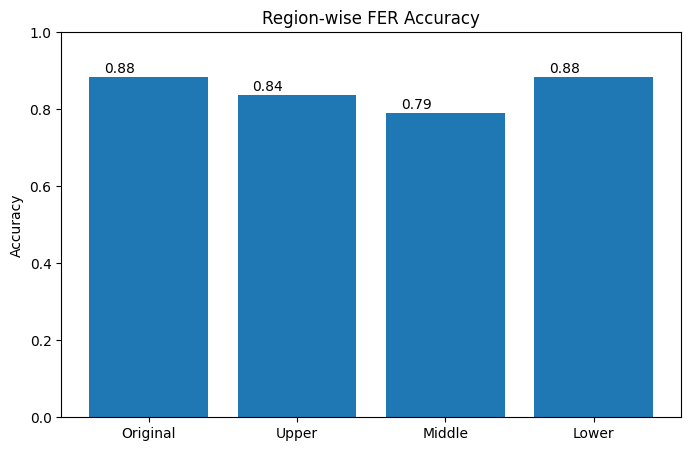

In [114]:
regions = ['Original', 'Upper', 'Middle', 'Lower']

accuracies = [
    acc_original,
    acc_upper,
    acc_middle,
    acc_lower
]

plt.figure(figsize=(8,5))

bars = plt.bar(regions, accuracies)

plt.ylabel("Accuracy")

plt.title("Region-wise FER Accuracy")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + 0.1,
        yval + 0.01,
        round(yval,2)
    )

plt.ylim(0,1)

plt.show()

In [115]:
print("\nORIGINAL FACE\n")

print(classification_report(y_test, pred_original))

print("\nUPPER FACE\n")

print(classification_report(y_test, pred_upper))

print("\nMIDDLE FACE\n")

print(classification_report(y_test, pred_middle))

print("\nLOWER FACE\n")

print(classification_report(y_test, pred_lower))


ORIGINAL FACE

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.75      1.00      0.86         6
           2       0.80      0.57      0.67         7
           3       1.00      1.00      1.00         6
           4       0.83      0.83      0.83         6
           5       0.83      0.83      0.83         6
           6       1.00      1.00      1.00         6

    accuracy                           0.88        43
   macro avg       0.89      0.89      0.88        43
weighted avg       0.89      0.88      0.88        43


UPPER FACE

              precision    recall  f1-score   support

           0       0.75      1.00      0.86         6
           1       0.62      0.83      0.71         6
           2       1.00      0.86      0.92         7
           3       1.00      0.67      0.80         6
           4       0.75      0.50      0.60         6
           5       1.00      1.00      1.00      

In [116]:
emotion_names = [
    'Anger',
    'Disgust',
    'Fear',
    'Happy',
    'Sadness',
    'Surprise',
    'Neutral'
]

In [117]:
# EMOTION-WISE REGION CONTRIBUTION ANALYSIS

report_upper = classification_report(
    y_test,
    pred_upper,
    output_dict=True
)

report_middle = classification_report(
    y_test,
    pred_middle,
    output_dict=True
)

report_lower = classification_report(
    y_test,
    pred_lower,
    output_dict=True
)

# Store analysis results
emotion_analysis = []

for i, emotion in enumerate(emotion_names):

    upper_recall = report_upper[str(i)]['recall']

    middle_recall = report_middle[str(i)]['recall']

    lower_recall = report_lower[str(i)]['recall']

    recall_scores = {
        'Upper': upper_recall,
        'Middle': middle_recall,
        'Lower': lower_recall
    }
    best_region = max(recall_scores, key=recall_scores.get)

    emotion_analysis.append([
        emotion,
        round(upper_recall,2),
        round(middle_recall,2),
        round(lower_recall,2),
        best_region
    ])

df_emotion = pd.DataFrame(
    emotion_analysis,
    columns=[
        'Emotion',
        'Upper',
        'Middle',
        'Lower',
        'Best Region'
    ]
)
print("\nEmotion-wise Regional Contribution Analysis\n")

print(df_emotion)


Emotion-wise Regional Contribution Analysis

    Emotion  Upper  Middle  Lower Best Region
0     Anger   1.00    1.00   1.00       Upper
1   Disgust   0.83    1.00   1.00      Middle
2      Fear   0.86    0.57   0.71       Upper
3     Happy   0.67    1.00   1.00      Middle
4   Sadness   0.50    0.83   0.83      Middle
5  Surprise   1.00    0.50   0.67       Upper
6   Neutral   1.00    0.67   1.00       Upper


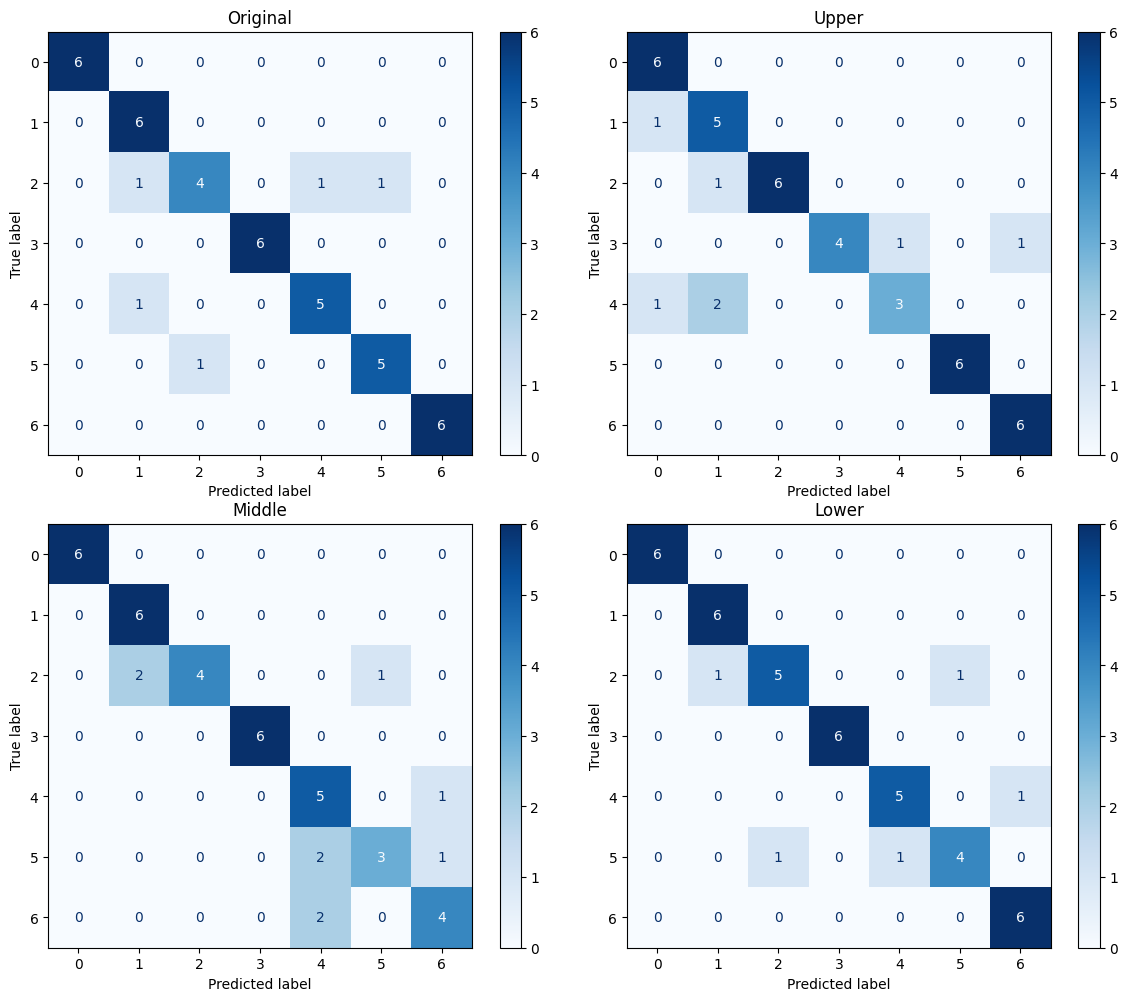

In [118]:
fig, axes = plt.subplots(2,2, figsize=(12,10))

# Original
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_original,
    ax=axes[0,0],
    cmap='Blues'
)

axes[0,0].set_title("Original")

# Upper
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_upper,
    ax=axes[0,1],
    cmap='Blues'
)

axes[0,1].set_title("Upper")

# Middle
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_middle,
    ax=axes[1,0],
    cmap='Blues'
)

axes[1,0].set_title("Middle")

# Lower
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_lower,
    ax=axes[1,1],
    cmap='Blues'
)

axes[1,1].set_title("Lower")

plt.tight_layout()

plt.show()

In [119]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from skimage.feature import hog

from sklearn.model_selection import train_test_split

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import StandardScaler

In [120]:
data = []
labels = []

emotion_map = {
    'anger':0,
    'contempt':1,
    'disgust':2,
    'fear':3,
    'happy':4,
    'sadness':5,
    'surprise':6
}

dataset_path = "/kaggle/input/datasets/shawon10/ckplus/CK+48"

# Loop through emotion folders
for emotion_folder in os.listdir(dataset_path):

    emotion_path = os.path.join(dataset_path, emotion_folder)

    if not os.path.isdir(emotion_path):
        continue

    label = emotion_map[emotion_folder]

    # Loop through images
    for img_name in os.listdir(emotion_path):

        img_path = os.path.join(emotion_path, img_name)

        try:

            img = Image.open(img_path).convert('L')

            # Resize
            img = img.resize((128,128))

            img = np.array(img)

            data.append(img)

            labels.append(label)

        except Exception as e:

            print("Error:", img_path)

data = np.array(data)
labels = np.array(labels)

print("Data Shape:", data.shape)
print("Labels:", np.unique(labels))

Data Shape: (981, 128, 128)
Labels: [0 1 2 3 4 5 6]


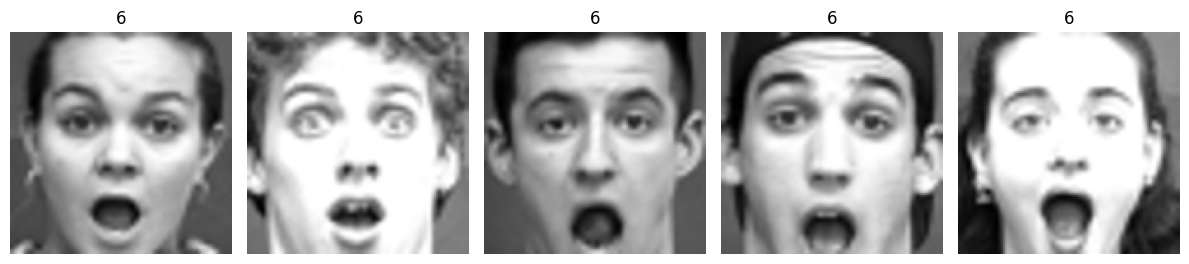

In [121]:
plt.figure(figsize=(12,4))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(data[i], cmap='gray')

    plt.title(labels[i])

    plt.axis('off')

plt.tight_layout()

plt.show()

In [122]:
upper_faces = []
middle_faces = []
lower_faces = []

for img in data:

    # Upper Region
    upper = img[20:60, :]

    # Middle Region
    middle = img[60:100, :]

    # Lower Region
    lower = img[80:120, :]

    upper_faces.append(upper)
    middle_faces.append(middle)
    lower_faces.append(lower)

upper_faces = np.array(upper_faces)
middle_faces = np.array(middle_faces)
lower_faces = np.array(lower_faces)

print(upper_faces.shape)
print(middle_faces.shape)
print(lower_faces.shape)

(981, 40, 128)
(981, 40, 128)
(981, 40, 128)


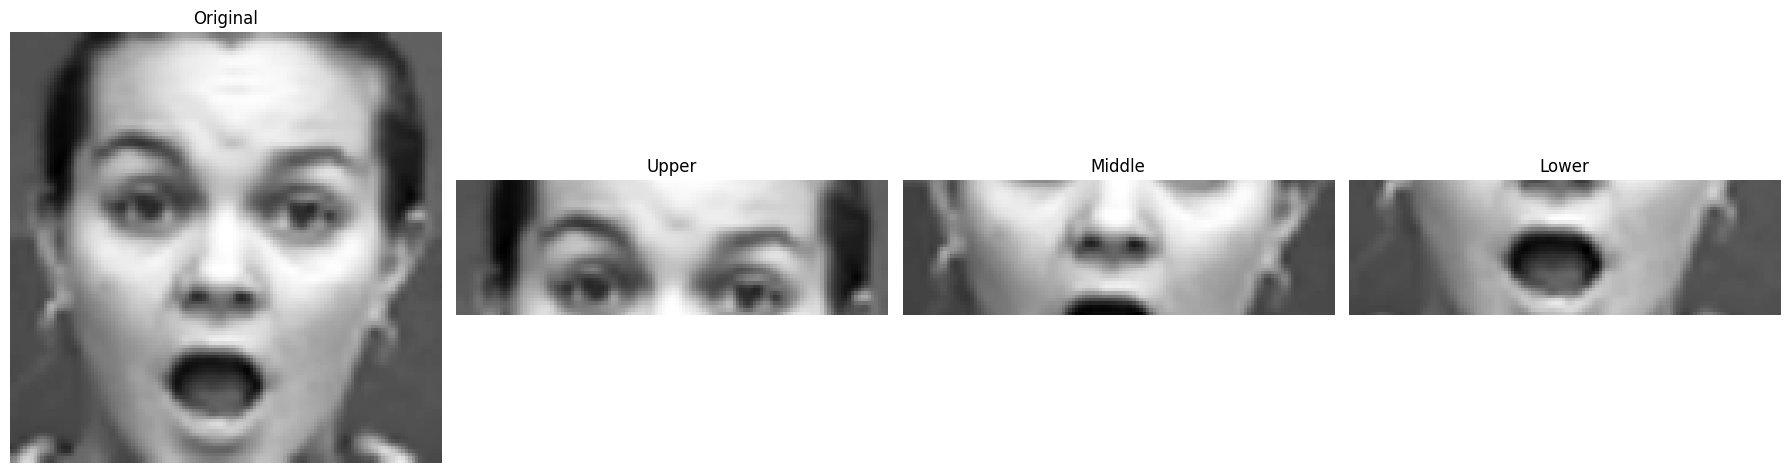

In [123]:
sample = 0

fig, ax = plt.subplots(1,4, figsize=(18,5))

ax[0].imshow(data[sample], cmap='gray')
ax[0].set_title("Original")

ax[1].imshow(upper_faces[sample], cmap='gray')
ax[1].set_title("Upper")

ax[2].imshow(middle_faces[sample], cmap='gray')
ax[2].set_title("Middle")

ax[3].imshow(lower_faces[sample], cmap='gray')
ax[3].set_title("Lower")

for a in ax:
    a.axis('off')

plt.tight_layout()

plt.show()

In [124]:
def extract_hog_features(images):

    features = []

    for img in images:

        hog_features = hog(
            img,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2),
            block_norm='L2-Hys'
        )

        features.append(hog_features)

    return np.array(features)

In [125]:
X_original = extract_hog_features(data)

X_upper = extract_hog_features(upper_faces)

X_middle = extract_hog_features(middle_faces)

X_lower = extract_hog_features(lower_faces)

print(X_original.shape)
print(X_upper.shape)
print(X_middle.shape)
print(X_lower.shape)

(981, 8100)
(981, 2160)
(981, 2160)
(981, 2160)


In [126]:
XO_train, XO_test, y_train, y_test = train_test_split(
    X_original,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

XU_train, XU_test, _, _ = train_test_split(
    X_upper,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

XM_train, XM_test, _, _ = train_test_split(
    X_middle,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

XL_train, XL_test, _, _ = train_test_split(
    X_lower,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [127]:
scaler_O = StandardScaler()
scaler_U = StandardScaler()
scaler_M = StandardScaler()
scaler_L = StandardScaler()

XO_train = scaler_O.fit_transform(XO_train)
XO_test = scaler_O.transform(XO_test)

XU_train = scaler_U.fit_transform(XU_train)
XU_test = scaler_U.transform(XU_test)

XM_train = scaler_M.fit_transform(XM_train)
XM_test = scaler_M.transform(XM_test)

XL_train = scaler_L.fit_transform(XL_train)
XL_test = scaler_L.transform(XL_test)

In [128]:
svm_original = SVC(kernel='linear')

svm_upper = SVC(kernel='linear')

svm_middle = SVC(kernel='linear')

svm_lower = SVC(kernel='linear')

svm_original.fit(XO_train, y_train)

svm_upper.fit(XU_train, y_train)

svm_middle.fit(XM_train, y_train)

svm_lower.fit(XL_train, y_train)

SVC(kernel='linear')

In [129]:
pred_original = svm_original.predict(XO_test)

pred_upper = svm_upper.predict(XU_test)

pred_middle = svm_middle.predict(XM_test)

pred_lower = svm_lower.predict(XL_test)

In [130]:
acc_original = accuracy_score(y_test, pred_original)

acc_upper = accuracy_score(y_test, pred_upper)

acc_middle = accuracy_score(y_test, pred_middle)

acc_lower = accuracy_score(y_test, pred_lower)

print("Original:", acc_original)

print("Upper:", acc_upper)

print("Middle:", acc_middle)

print("Lower:", acc_lower)

Original: 1.0
Upper: 0.9949238578680203
Middle: 0.9949238578680203
Lower: 1.0


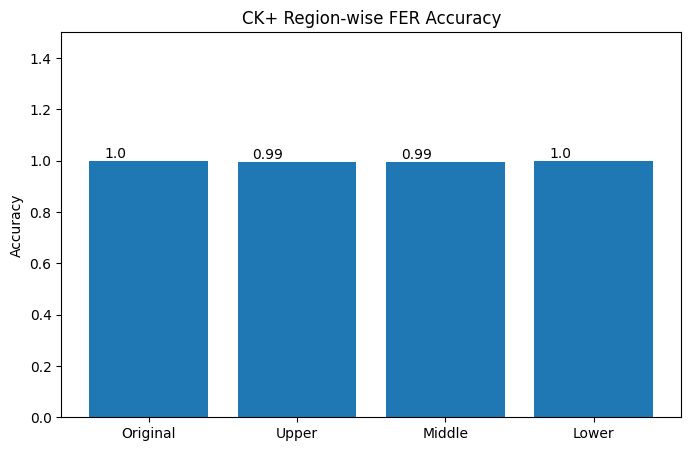

In [131]:
regions = ['Original', 'Upper', 'Middle', 'Lower']

accuracies = [
    acc_original,
    acc_upper,
    acc_middle,
    acc_lower
]

plt.figure(figsize=(8,5))

bars = plt.bar(regions, accuracies)

plt.ylabel("Accuracy")

plt.title("CK+ Region-wise FER Accuracy")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + 0.1,
        yval + 0.01,
        round(yval,2)
    )

plt.ylim(0,1.5)

plt.show()

In [134]:
report_upper = classification_report(
    y_test,
    pred_upper,
    output_dict=True
)

report_middle = classification_report(
    y_test,
    pred_middle,
    output_dict=True
)

report_lower = classification_report(
    y_test,
    pred_lower,
    output_dict=True
)

emotion_analysis = []

for i, emotion in enumerate(emotion_names):


    upper_recall = report_upper[str(i)]['recall']

    middle_recall = report_middle[str(i)]['recall']

    lower_recall = report_lower[str(i)]['recall']

    recall_scores = {
        'Upper': upper_recall,
        'Middle': middle_recall,
        'Lower': lower_recall
    }

    # Best region
    best_region = max(recall_scores, key=recall_scores.get)

    emotion_analysis.append([
        emotion,
        round(upper_recall,2),
        round(middle_recall,2),
        round(lower_recall,2),
        best_region
    ])

# Create dataframe
df_emotion = pd.DataFrame(
    emotion_analysis,
    columns=[
        'Emotion',
        'Upper',
        'Middle',
        'Lower',
        'Best Region'
    ]
)

print("\nCK+ Emotion-wise Regional Contribution Analysis\n")

print(df_emotion)


CK+ Emotion-wise Regional Contribution Analysis

    Emotion  Upper  Middle  Lower Best Region
0     Anger   1.00    1.00    1.0       Upper
1  Contempt   1.00    1.00    1.0       Upper
2   Disgust   1.00    1.00    1.0       Upper
3      Fear   0.93    1.00    1.0      Middle
4     Happy   1.00    1.00    1.0       Upper
5   Sadness   1.00    1.00    1.0       Upper
6  Surprise   1.00    0.98    1.0       Upper


In [ ]:
#now best feature fusion technique 
#which fau is good for which model